In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
from time import time
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys

# Lecture 14: Import MNIST Images

In [ ]:
transform = transforms.ToTensor()
train_data = datasets.MNIST(root=r"../datasets/mnist", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root=r"../datasets/mnist", train=False, download=True, transform=transform)
train_data, test_data

# Lecture 15: Convolutional and Pooling Layers

## Quick Note for Convolutional and Pooling Layers:
1. Out put size equation:<center>$O=\frac{W-K+2{\times}P}{S}+1$</center>
    * O: Output Size
    * W: input Volume
    * K: Kernel Size
    * P: Padding
    * S: Stride
2. If padding is not set, we will lose image boundary pixels.
3. Max pooling will round down if output size has remainder.

## Section 1: Create a Batch Size for Images
Batch size refers to the number of individual data samples that are processed together in a single forward pass and backward pass during the training of a neural network.

In [3]:
batch_size = 512
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

## Section 2: Define CNN Model by Describing Convolutional Layers

In [4]:
conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1)
conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1)

## Section 3: Grab 1 MNIST record/image.

In [5]:
for idx, (X_train, y_train) in enumerate(train_data):
    break

X = X_train.reshape(1, 1, 28, 28)
X.shape

torch.Size([1, 1, 28, 28])

## Section 4: Pass Through 2 Convolutional Layers

In [6]:
X = F.relu(conv1(X))
print(X.shape)

X = F.relu(conv2(X))
print(X.shape)

torch.Size([1, 6, 26, 26])
torch.Size([1, 16, 24, 24])


## Section 5: Pass Through Pooling Layer

In [7]:
X = F.max_pool2d(X, kernel_size=2, stride=2)
X.shape

torch.Size([1, 16, 12, 12])

# Lecture 16: Convolutional Neural Network Model

## Section 1: Config CNN Model
* Create Convolutional Layers and Pooling Layers
* Connect all Layers

In [8]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1)
        self.conv2 = nn.LazyConv2d(out_channels=16, kernel_size=3, stride=1)

        self.fc1 = nn.LazyLinear(out_features=128)
        self.fc2 = nn.LazyLinear(out_features=96)
        self.fc3 = nn.LazyLinear(out_features=10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = x.flatten(start_dim=1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = F.log_softmax(x, dim=1)

        return x

## Section 2: Create an Instance of CNN Model

In [9]:
torch.manual_seed(3)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model = ConvolutionalNetwork().to(device)
device

device(type='mps')

## Section 3: Create Loss Function and Optimizor

In [10]:
criterion = nn.CrossEntropyLoss()
optimizor = torch.optim.Adam(model.parameters(), lr=0.001)

# Lecture 17: Train and Test CNN Network

## Section 1: Create Tracking Variables

In [11]:
epochs = 10
total_train_losses = []
total_test_losses = 0

toral_train_accuracies = []
toral_test_accuracies = 0

## Section 2: Train CNN Model

In [12]:
for idx in range(epochs):
    train_losses = []
    train_accuracies = []
    t0 = time()

    pbar_train = tqdm(train_loader, desc=f"Epoch {idx+1}",unit="batch", file=sys.stdout)
    for batch, (X_train, y_train) in enumerate(pbar_train):
        X_train = X_train.to(device)
        y_train = y_train.to(device)

        y_pred = model(X_train)

        loss = criterion(y_pred, y_train)
        train_losses.append(loss.item())

        batch_correct = (y_pred.argmax(dim=1) == y_train).sum()
        batch_accuracy = 100* batch_correct / batch_size
        train_accuracies.append(batch_accuracy.cpu().item())

        optimizor.zero_grad()
        loss.backward()
        optimizor.step()

        run_time = time() - t0
        pbar_train.set_postfix({"loss": f"{np.mean(train_losses):.4f}", "Time": f"{run_time:.2f}s",
                                "Accuracy": f"{(np.mean(train_accuracies)):.2f}%"})

    total_train_losses.append(np.mean(train_losses))
    toral_train_accuracies.append(np.mean(train_accuracies))

Epoch 10: 100%|██████████| 118/118 [00:01<00:00, 91.47batch/s, loss=0.0281, Time=1.29s, Accuracy=98.46%]


## Section 3: Test and Save CNN Model

In [13]:
pbar_test = tqdm(test_loader, desc="Test Progress", unit="batch", file=sys.stdout)

with torch.no_grad():
    test_losses = []
    test_accuracies = []
    t0 = time()

    for batch, (X_test, y_test) in enumerate(pbar_test):
        X_test, y_test = X_test.to(device), y_test.to(device)
        y_eval = model(X_test)

        loss = criterion(y_eval, y_test)
        test_losses.append(loss.item())

        test_correct = (y_eval.argmax(dim=1) == y_test).sum()
        test_accuracy = 100 * test_correct / batch_size
        test_accuracies.append(test_accuracy.cpu().item())

        run_time = time() - t0
        pbar_test.set_postfix({"Loss": f"{np.mean(test_losses):.4f}", "Time": f"{run_time:.3f}s", "Accuracy": f"{np.mean(test_accuracies):.2f}%"})

    total_test_losses = np.mean(test_losses)
    total_test_accuracies = np.mean(test_accuracies)


torch.save(model.state_dict(), r"../models/MNIST.pt")

Test Progress: 100%|██████████| 20/20 [00:00<00:00, 103.16batch/s, Loss=0.0400, Time=0.193s, Accuracy=96.42%]


# Lecture 18: Graph CNN Model Result

# Section 1: Plot CNN Loss

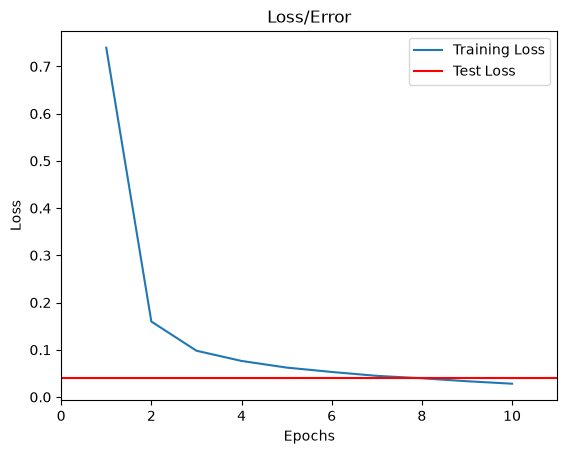

In [14]:
plt.plot(np.arange(epochs)+1, total_train_losses, label="Training Loss")
plt.axhline(y = total_test_losses, label="Test Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss/Error")
plt.xlim(0, epochs+1)
plt.legend()

## Section 2: Plot CNN Accuracy

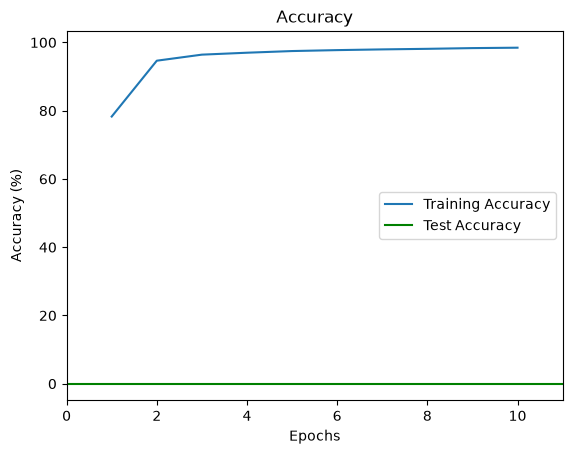

In [15]:
plt.plot(np.arange(epochs)+1, toral_train_accuracies, label="Training Accuracy")
plt.axhline(y = toral_test_accuracies, label="Test Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy")
plt.xlim(0, epochs+1)
plt.legend()

# Lecture 19:

## Section 1: Grab an Image
* Tensor with an image, and a label at the end.
* Image shape = [1, 28, 28]

In [16]:
image_idx = 1000
image = test_data[image_idx][0]
image_label = test_data[image_idx][1]
image_label

9

## Section 2: Show the Image

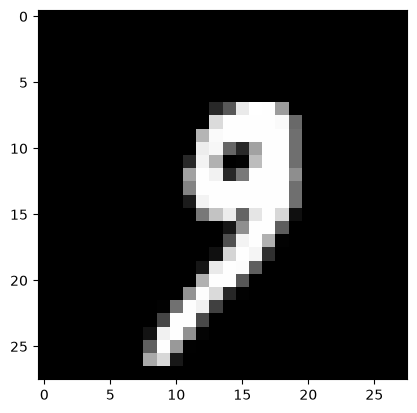

In [17]:
plt.imshow(image.reshape(28, 28), cmap="gray")

## Section 3: Pass the image through the CNN model
* Reshape image to [1 batch size, 1 color channel, 28 width, 28 high]

In [18]:
with torch.no_grad():
    input_tensor = image.reshape([1, 1, 28, 28]).to(device)
    y_predicted_number = model(input_tensor).argmax().cpu().item()

y_predicted_number

9